In [1]:
import sys, os
os.chdir('..')  # set CWD to project root
sys.path.insert(0, 'src')

import pandas as pd

from etl import *
from regression import *
from sims_engine import *

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
%load_ext autoreload
%autoreload 2

In [ ]:
CONFIG = {
    'elo_date': '2026-04-08',  # date for elo ratings from clubelo.com
    'opta_date': '2026-04-08',  # date for elo ratings from the opta -> clubelo regression; elo_date from day X is before the games are played, for opta it depends
    'number_of_sims': 1000,
    'league_id': 106,
    'season': 2025,
    'head_size': 36,
    'country_code_elo': None,  # use this attr. to use elo ratings from clubelo.com
    'country_code_api': 'POL',  # use this attr. to use elo ratings from the opta -> clubelo regression
    'stdev': 0,
    'update_fixtures': True,
    'is_european_league': False,
    'round_no': 27,
    'point_deductions': {'Lechia Gdansk': 5}
}
code = CONFIG['country_code_elo'] if CONFIG['country_code_elo'] is not None else CONFIG['country_code_api']
CONFIG['sorting_order'] = get_sorting_order_for_country_code(code)

In [5]:
download_elo_data(CONFIG['elo_date'])

18 ELO teams matched.
24 Opta teams matched.
13 unmatched Opta teams found, see transformed/opta/opta_unmatched_map.csv:
33 unmatched Opta teams found, see transformed/opta/opta_unmatched_elo_df.csv:
18 teams used for regression.
0.907 R^2 score
y = 28.22 * x + -795.85


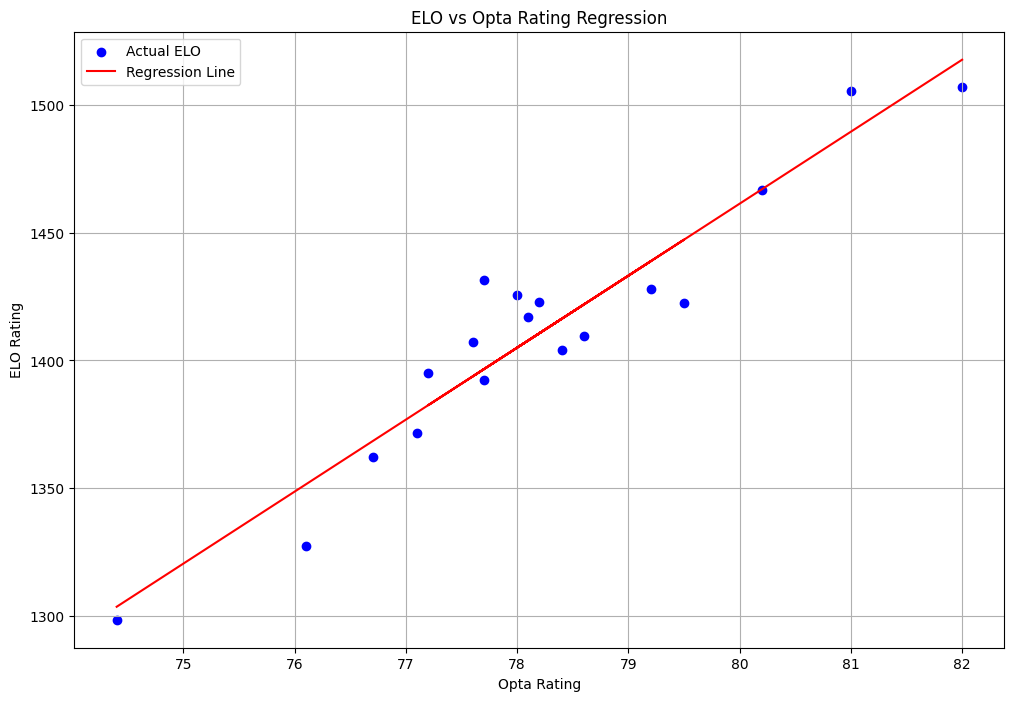

In [7]:
main_regression(**CONFIG)

In [8]:
standings_df, fixtures_matrix = build_historical_standings_table_after_at_most_n_rounds(**CONFIG)
standings_df.head(CONFIG['head_size'])

,Club,Elo,Matches played,Wins,Draws,Losses,Goals for,Goals against,Goal difference,Goals away,Points,Random order,H2H
1,Lech Poznan,1517.88,27,12,9,6,46,37,9,17,45,5,1
2,Gornik Zabrze,1447.34,27,12,6,9,39,32,7,12,42,8,1
3,Jagiellonia,1467.09,27,11,9,7,43,34,9,14,42,6,2
4,Zaglebie Lubin,1410.66,27,11,8,8,41,33,8,17,41,15,1
5,Wisla Plock,1379.62,27,10,9,8,28,26,2,13,39,16,1
6,Raków Częstochowa,1489.66,27,11,6,10,36,34,2,22,39,0,2
7,GKS Katowice,1421.94,27,12,3,12,36,35,1,15,39,14,3
8,Motor Lublin,1396.55,27,9,11,7,36,39,-3,17,38,1,1
9,Lechia Gdansk,1416.30,27,12,6,9,55,50,5,22,37,10,1
10,Cracovia Krakow,1407.83,27,9,9,9,31,31,0,14,36,17,1


In [9]:
CONFIG['update_fixtures'] = False

In [10]:
standings_df['Elo'].mean()

1410.8127777777781

In [11]:
float(round(standings_df['Points'].sum() / standings_df['Matches played'].sum(), 2))

1.35

In [12]:
sample_season = simulate_season_after_n_rounds(**CONFIG, standings_df=standings_df)
sample_season.head(CONFIG['head_size'])

,Club,Elo,Matches played,Wins,Draws,Losses,Goals for,Goals against,Goal difference,Goals away,Points,Random order,H2H
1,Gornik Zabrze,1447.34,34,17,7,10,50,35,15,17,58,11,1
2,Jagiellonia,1467.09,34,16,9,9,53,38,15,20,57,9,1
3,Raków Częstochowa,1489.66,34,17,6,11,48,36,12,28,57,1,2
4,Lech Poznan,1517.88,34,14,11,9,52,45,7,21,53,5,1
5,Lechia Gdansk,1416.30,34,15,8,11,63,56,7,28,48,7,1
6,Pogon Szczecin,1396.55,34,14,5,15,45,47,-2,16,47,0,1
7,Arka Gdynia,1351.40,34,13,7,14,37,50,-13,9,46,13,1
8,Zaglebie Lubin,1410.66,34,12,10,12,45,43,2,17,46,3,2
9,Wisla Plock,1379.62,34,12,10,12,33,35,-2,15,46,17,3
10,Legia Warszawa,1438.87,34,10,15,9,41,36,5,18,45,2,1


In [13]:
float(round(sample_season['Points'].sum() / sample_season['Matches played'].sum(), 2))

1.36

In [14]:
simulate_odds(**CONFIG, standings_df=standings_df).head(CONFIG['head_size'])

,Home Team,Away Team,Odds H,Odds D,Odds A
0,GKS Katowice,Wisla Plock,2.12,3.66,3.92
1,Raków Częstochowa,Widzew Łódź,1.76,4.19,5.15
2,Gornik Zabrze,Cracovia Krakow,2.13,3.65,3.90
3,Jagiellonia,Lech Poznan,2.71,3.43,2.94
4,Nieciecza,Piast Gliwice,3.15,3.45,2.55
5,Radomiak Radom,Motor Lublin,2.45,3.48,3.29
6,Pogon Szczecin,Legia Warszawa,2.65,3.43,3.02
7,Lechia Gdansk,Korona Kielce,2.22,3.58,3.69
8,Arka Gdynia,Zaglebie Lubin,2.78,3.42,2.87


In [18]:
# full table sim
results, h2h_table = run_full_table_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix)
results.head(CONFIG['head_size'])

100%|██████████| 1000/1000 [00:15<00:00, 65.22it/s]

1000 simulations


,Club,Elo,xPts,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
1,Lech Poznan,1517.88,57.55,69.8,16.4,6.7,3.1,1.9,1.6,0.3,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Gornik Zabrze,1447.34,52.36,8.4,22.6,19.4,13.1,11.2,8.8,5.5,4.1,2.9,1.5,0.9,1.0,0.4,0.2,0.0,0.0,0.0,0.0
3,Jagiellonia,1467.09,52.16,9.2,20.4,18.0,14.9,11.5,8.9,6.2,4.3,3.0,1.9,0.9,0.4,0.4,0.0,0.0,0.0,0.0,0.0
4,Zaglebie Lubin,1410.66,50.91,4.1,15.0,14.9,15.2,13.4,10.4,7.3,6.9,3.7,2.9,3.0,1.2,1.0,0.7,0.3,0.0,0.0,0.0
5,Raków Częstochowa,1489.66,50.63,4.2,10.9,13.2,14.2,13.4,11.1,9.0,7.2,5.7,4.4,2.7,1.7,1.2,0.4,0.5,0.2,0.0,0.0
6,GKS Katowice,1421.94,48.70,1.8,4.9,8.0,8.4,10.7,11.5,10.9,10.3,9.5,8.6,4.8,4.5,2.5,2.0,1.1,0.5,0.0,0.0
7,Wisla Plock,1379.62,48.13,0.9,4.9,6.7,9.3,9.0,10.6,11.6,10.8,9.0,6.3,6.6,5.7,3.2,3.2,1.3,0.8,0.1,0.0
8,Lechia Gdansk,1416.30,46.72,0.6,1.9,3.3,5.1,7.1,8.3,9.4,9.8,9.8,9.5,8.7,7.4,7.1,5.4,3.3,2.5,0.8,0.0
9,Motor Lublin,1396.55,46.43,0.3,1.2,3.2,4.1,6.1,7.6,8.8,9.3,9.8,10.5,10.6,8.6,7.5,5.4,4.4,2.3,0.3,0.0
10,Cracovia Krakow,1407.83,45.91,0.5,0.4,3.3,4.1,4.2,5.2,7.9,8.5,10.8,11.9,8.8,9.2,7.5,6.2,6.0,3.6,1.8,0.1


In [19]:
h2h_table.head(CONFIG['head_size'])

,Lech Poznan,Gornik Zabrze,Jagiellonia,Zaglebie Lubin,Wisla Plock,Raków Częstochowa,GKS Katowice,Motor Lublin,Lechia Gdansk,Cracovia Krakow,Korona Kielce,Piast Gliwice,Radomiak Radom,Pogon Szczecin,Legia Warszawa,Arka Gdynia,Widzew Łódź,Nieciecza
Lech Poznan,0.0,88.5,86.0,91.4,95.2,92.6,95.1,98.0,98.3,98.6,99.6,99.4,99.7,99.6,99.7,99.9,100.0,100.0
Gornik Zabrze,11.5,0.0,50.5,59.2,77.9,66.6,78.1,87.5,86.6,92.7,90.9,95.4,96.3,98.2,95.1,98.6,99.6,100.0
Jagiellonia,14.0,49.5,0.0,58.9,79.4,59.6,76.4,91.1,84.6,92.3,93.0,92.8,97.8,97.0,96.4,99.1,99.9,100.0
Zaglebie Lubin,8.6,40.8,41.1,0.0,71.8,57.1,64.8,80.9,81.9,82.1,90.7,90.3,94.2,94.1,92.0,97.8,99.5,100.0
Wisla Plock,4.8,22.1,20.6,28.2,0.0,35.9,43.9,64.0,60.4,71.7,77.6,76.5,85.8,86.9,82.1,93.5,96.5,99.9
Raków Częstochowa,7.4,33.4,40.4,42.9,64.1,0.0,68.6,79.7,77.3,79.5,85.7,86.7,95.1,95.6,92.9,97.4,99.4,100.0
GKS Katowice,4.9,21.9,23.6,35.2,56.1,31.4,0.0,69.7,64.5,67.4,76.1,76.0,92.5,88.7,84.7,96.0,97.6,100.0
Motor Lublin,2.0,12.5,8.9,19.1,36.0,20.3,30.3,0.0,45.2,55.7,61.8,66.2,80.5,74.8,68.2,90.1,93.6,100.0
Lechia Gdansk,1.7,13.4,15.4,18.1,39.6,22.7,35.5,54.8,0.0,56.9,61.4,64.3,76.5,82.1,71.7,91.2,91.9,99.9
Cracovia Krakow,1.4,7.3,7.7,17.9,28.3,20.5,32.6,44.3,43.1,0.0,58.4,56.1,72.7,73.3,67.6,84.0,94.2,99.8


In [22]:
# top 1, 2, 3, 4 sim
results = run_top_n_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix, top_n=[1, 2, 3, 4])
results.head(CONFIG['head_size'])

100%|██████████| 1000/1000 [00:15<00:00, 66.03it/s]

1000 simulations
Top N: [1, 2, 3, 4]


,Club,Elo,xPts,Top 1 %,Top 1 Odds,Top 2 %,Top 2 Odds,Top 3 %,Top 3 Odds,Top 4 %,Top 4 Odds
1,Lech Poznan,1517.88,57.32,66.7,1.5,86.7,1.15,93.6,1.07,96.7,1.03
2,Jagiellonia,1467.09,52.60,10.9,9.17,35.6,2.81,54.0,1.85,67.3,1.49
3,Gornik Zabrze,1447.34,52.26,9.2,10.87,28.0,3.57,48.5,2.06,65.3,1.53
4,Zaglebie Lubin,1410.66,50.73,4.5,22.22,17.8,5.62,31.7,3.15,46.5,2.15
5,Raków Częstochowa,1489.66,50.50,3.7,27.03,14.4,6.94,28.1,3.56,42.3,2.36
6,GKS Katowice,1421.94,48.54,2.1,47.62,6.2,16.13,12.7,7.87,21.6,4.63
7,Wisla Plock,1379.62,48.17,1.8,55.56,4.8,20.83,12.3,8.13,21.3,4.69
8,Lechia Gdansk,1416.30,46.55,0.5,200.0,1.8,55.56,5.7,17.54,10.0,10.0
9,Motor Lublin,1396.55,46.45,0.5,200.0,2.7,37.04,5.7,17.54,10.8,9.26
10,Pogon Szczecin,1396.55,42.57,0.1,1000.0,0.2,500.0,0.4,250.0,1.2,83.33


In [21]:
# bottom 1, 3 sim
results = run_top_n_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix, top_n=[1, 3], reverse=True)
results.head(CONFIG['head_size'])

100%|██████████| 1000/1000 [00:15<00:00, 64.55it/s]

1000 simulations
Top N: [1, 3]
Reverse: TRUE


,Club,Elo,xPts,Top 1 %,Top 1 Odds,Top 3 %,Top 3 Odds
1,Nieciecza,1303.43,32.48,86.6,1.15,98.1,1.02
2,Widzew Łódź,1368.33,39.24,6.9,14.49,62.7,1.59
3,Arka Gdynia,1351.40,40.56,4.0,25.0,49.4,2.02
4,Legia Warszawa,1438.87,43.31,0.9,111.11,15.5,6.45
5,Pogon Szczecin,1396.55,42.54,0.8,125.0,23.3,4.29
6,Radomiak Radom,1382.44,42.61,0.8,125.0,22.7,4.41
7,Jagiellonia,1467.09,52.34,0.0,N/A,0.0,N/A
8,Piast Gliwice,1405.01,44.77,0.0,N/A,9.7,10.31
9,Korona Kielce,1393.73,45.11,0.0,N/A,6.1,16.39
10,Lech Poznan,1517.88,57.44,0.0,N/A,0.0,N/A
